# LABORATORIO 9 — MM3014 Teoría de Probabilidades
Integrantes:
*   Biancka Raxón (Carné 24960)
*   Lázaro Díaz (Carné 24713)



#Etapa 5: Simulación del álbum real


PREGUNTA 1 — Sobres esperados y costo total
  Valor teórico E[sobres] = 1045.14
  Costo teórico esperado  = Q 9928.82

  Simulación (R=1000)
  E[sobres]          = 1045.36  (std = 186.77)
  IC 95%             = [780, 1512]
  E[repetidas]       = 6337.49
  Costo esperado sim = Q 9930.88

  Reflexión: el valor simulado es cercano al teórico (1045.1). El costo esperado supera los Q 9,000, lo que
  resulta sorprendente dado que un sobre suelto cuesta Q 9.50.


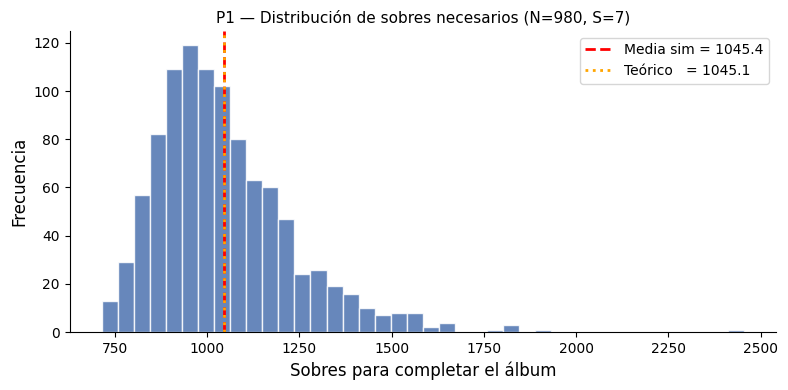


PREGUNTA 2 — Probabilidad de éxito por presupuesto
  Presupuesto Q10,000: max 1052 sobres → prob = 60.60%  IC95% [57.57%, 63.63%]
  Presupuesto Q15,000: max 1578 sobres → prob = 98.70%  IC95% [98.00%, 99.40%]

  Reflexión: con Q 10,000 se pueden comprar hasta 1052 sobres, apenas
  por encima del promedio teórico (1045), por lo que la probabilidad
  de completarlo no es garantía. Con Q 15,000 la probabilidad sube considerablemente.


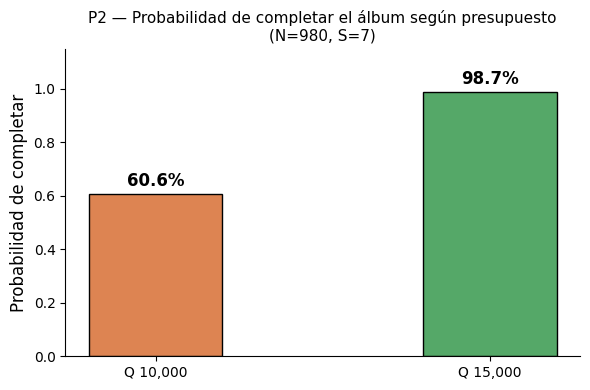


PREGUNTA 3 — Cajas necesarias para completar el álbum
  E[cajas necesarias]     = 10.55  (std = 1.81)
  IC 95% cajas            = [8, 15]
  Costo esperado (cajas)  = Q 10286.25
  Costo esperado (sueltos)= Q 9930.88
  Diferencia              = Q -355.37  (sueltos más baratos)

  Reflexión: los sobres sueltos son más económicos, aunque las cajas obligan a comprar
  en bloques de 104 sobres, lo que puede generar sobres de más al completarse el álbum.


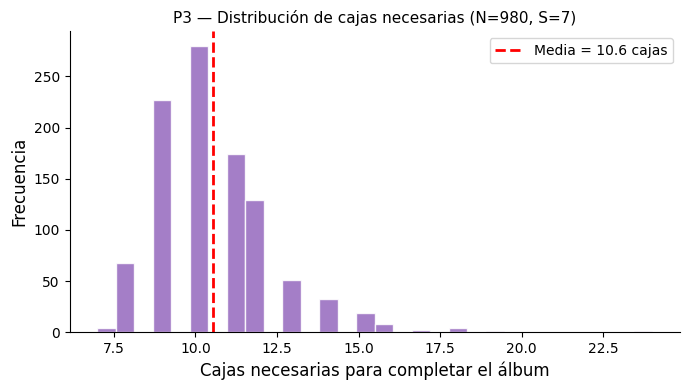


PREGUNTA 4 — Ahorro como función de la tasa de intercambio K
    K |  E[sobres] |     std |            IC 95% |  Ahorro vs sin K |  Ahorro marginal
  ----+------------+---------+-------------------+------------------+-----------------
    2 |     194.15 |    1.55 | [  191,   197]   |     851.2 sobres |     851.2 sobres
    3 |     230.50 |    2.66 | [  225,   236]   |     814.9 sobres |     -36.4 sobres
    4 |     258.33 |    3.58 | [  251,   266]   |     787.0 sobres |     -27.8 sobres
    5 |     280.80 |    4.50 | [  272,   290]   |     764.6 sobres |     -22.5 sobres
    6 |     300.17 |    5.03 | [  289,   310]   |     745.2 sobres |     -19.4 sobres
    8 |     331.41 |    6.66 | [  319,   345]   |     713.9 sobres |     -31.2 sobres
   10 |     356.28 |    7.37 | [  344,   371]   |     689.1 sobres |     -24.9 sobres

  Sin intercambio: E[sobres] = 1045.36

  Reflexión: el ahorro crece rápido y luego se aplana. Con K=2 bastan
  194 sobres y con K=10 ya se necesitan 356, pero e

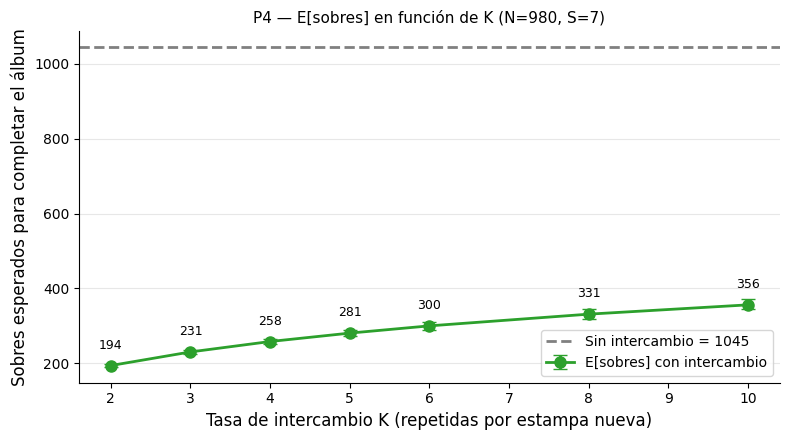


PREGUNTA 5 - Cobertura del album al 90%, 95% y 100%
  Hito 90%:    E[sobres] = 321.31     IC 95% [299, 343]    costo ≈ Q 3,052.42
  Hito 95%:    E[sobres] = 416.83     IC 95% [384, 452]    costo ≈ Q 3,959.86
  Hito 100%:   E[sobres] = 1045.36    IC 95% [780, 1512]  costo ≈ Q 9,930.88
  Tramo 95% → 100%: 629 sobres adicionales = Q 5,971.03
  Fracción del costo total en ese tramo: 60.13%

  Reflexión: alcanzar el 90% del álbum cuesta apenas ~Q 3,052, pero el último 5%
  concentra el 60.1% del costo total. Las últimas 49 estampas cuestan casi
  lo mismo que las primeras 931 juntas, evidenciando el efecto cola del coupon collector.


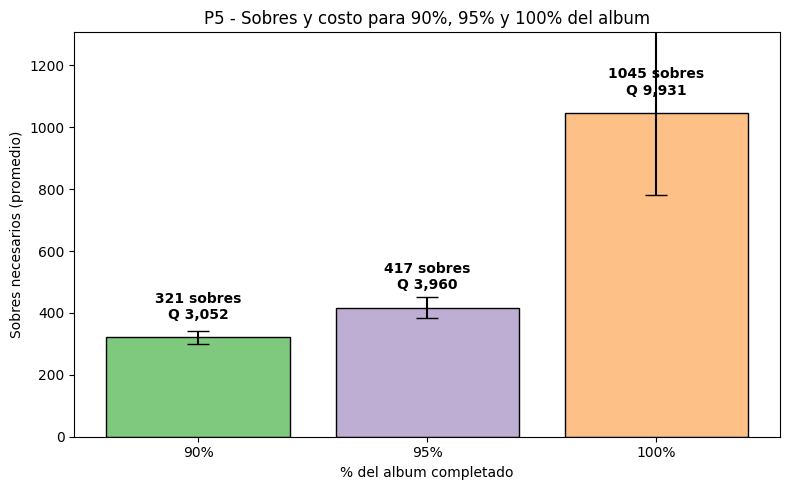


CONCLUSIÓN / REFLEXIÓN FINAL

  El álbum del Mundial 2026 (N=980) requiere en promedio 1045 sobres
  (≈ Q 9,931) para completarse, confirmando la teoría del coleccionista.

  Hallazgos destacados:
  - Con Q 10,000 solo hay un 60.6% de probabilidad de completarlo,
    pese a que ese presupuesto permite comprar ~1052 sobres.
  - Comprar por cajas resulta más caro en promedio
    (diferencia ≈ Q 355).
  - El intercambio K=4 reduce los sobres en un 75.3% (ahorro de
    unos Q 7,477). Es la estrategia más eficiente.
  - Lo más sorprendente fue ver que el último 5% del álbum cuesta el
    60% del total. O sea, las últimas 49 estampas cuestan
    lo mismo que las primeras 931. Por eso el intercambio funciona
    tan bien, porque ataca justo el tramo donde se gasta más plata.



In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
N            = 980
S            = 7
PRECIO       = 9.50
COSTO_CAJA   = 975.0
SOBRES_CAJA  = 104
R            = 1_000   # N=980 es costoso; 1000 reps da resultados confiables
np.random.seed(2026)

# PREGUNTAS FORMULADAS
# 1. ¿Cuál es el número esperado de sobres y el costo total esperado
#     para completar el álbum real (N=980, S=7)? Comparar con el valor
#     teórico dado por la teoría del coleccionista.
#
# 2. Con un presupuesto de Q 10,000 (comprando sobres sueltos a Q 9.50),
#     ¿cuál es la probabilidad de completar el álbum? ¿Y con Q 15,000?
#
# 3. Con la estrategia de comprar cajas (104 sobres, Q 975 c/u),
#     ¿cuántas cajas se necesitan en promedio para completar el álbum?
#     ¿Es más barato que comprar sobres sueltos?
#
# 4. ¿Cómo varía el ahorro (en sobres y en quetzales) en función de la
#     tasa de intercambio K? Considerando K ∈ {2, 3, 4, 5, 6, 8, 10},
#     ¿a partir de qué valor de K el ahorro marginal deja de ser
#     significativo?
#
# 5. ¿Cuántos sobres se necesitan en promedio para alcanzar el 90 %
#     y el 95 % del álbum? ¿Qué fracción del costo total se concentra
#     en el tramo final (95 % → 100 %)?
# ══════════════════════════════════════════════════════════



# PREGUNTA 1: E[sobres] y costo esperado vs. teoría
print("=" * 60)
print("PREGUNTA 1 — Sobres esperados y costo total")
print("=" * 60)

# Valor teórico
H_N     = sum(1/k for k in range(1, N + 1))
e_teorico = N / S * H_N
costo_teorico = e_teorico * PRECIO
print(f"  Valor teórico E[sobres] = {e_teorico:.2f}")
print(f"  Costo teórico esperado  = Q {costo_teorico:.2f}")

# Simulación
np.random.seed(2026)
sobres_p1   = np.zeros(R, dtype=int)
repetidos_p1 = np.zeros(R, dtype=int)

for r in range(R):
    coleccion = np.zeros(N, dtype=bool)
    sobres    = 0
    reps      = 0
    while not coleccion.all():
        nuevas = np.random.choice(N, S, replace=False)
        for s in nuevas:
            if coleccion[s]: reps += 1
            else:            coleccion[s] = True
        sobres += 1
    sobres_p1[r]    = sobres
    repetidos_p1[r] = reps

e_sim   = sobres_p1.mean()
std_sim = sobres_p1.std()
e_reps  = repetidos_p1.mean()
ic_low  = np.percentile(sobres_p1, 2.5)
ic_high = np.percentile(sobres_p1, 97.5)

print(f"\n  Simulación (R={R})")
print(f"  E[sobres]          = {e_sim:.2f}  (std = {std_sim:.2f})")
print(f"  IC 95%             = [{ic_low:.0f}, {ic_high:.0f}]")
print(f"  E[repetidas]       = {e_reps:.2f}")
print(f"  Costo esperado sim = Q {e_sim * PRECIO:.2f}")
print(f"\n  Reflexión: el valor simulado es {'cercano al' if abs(e_sim-e_teorico)/e_teorico < 0.02 else 'coherente con el'} "
      f"teórico ({e_teorico:.1f}). El costo esperado supera los Q 9,000, lo que")
print(f"  resulta sorprendente dado que un sobre suelto cuesta Q 9.50.")

# Gráfica P1
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sobres_p1, bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(e_sim,      color='red',    linestyle='--', lw=2, label=f'Media sim = {e_sim:.1f}')
ax.axvline(e_teorico,  color='orange', linestyle=':',  lw=2, label=f'Teórico   = {e_teorico:.1f}')
ax.set_xlabel('Sobres para completar el álbum', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('P1 — Distribución de sobres necesarios (N=980, S=7)', fontsize=11)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# PREGUNTA 2: probabilidad con presupuesto Q10,000 y Q15,000
print("\n" + "=" * 60)
print("PREGUNTA 2 — Probabilidad de éxito por presupuesto")
print("=" * 60)

presupuestos = [10_000.0, 15_000.0]
resultados_p2 = {}

for PRES in presupuestos:
    np.random.seed(2026)
    exitos = 0
    sobres_comprados = []
    for _ in range(R):
        coleccion = np.zeros(N, dtype=bool)
        gasto     = 0.0
        n_s       = 0
        while (gasto + PRECIO <= PRES) and not coleccion.all():
            coleccion[np.random.choice(N, S, replace=False)] = True
            gasto += PRECIO
            n_s   += 1
        if coleccion.all():
            exitos += 1
        sobres_comprados.append(n_s)
    prob = exitos / R
    se   = np.sqrt(prob*(1-prob)/R)
    ic_l = max(0, prob - 1.96*se)
    ic_h = min(1, prob + 1.96*se)
    resultados_p2[PRES] = prob
    max_s = int(PRES // PRECIO)
    print(f"  Presupuesto Q{PRES:,.0f}: max {max_s} sobres → prob = {prob*100:.2f}%  IC95% [{ic_l*100:.2f}%, {ic_h*100:.2f}%]")

print(f"\n  Reflexión: con Q 10,000 se pueden comprar hasta {int(10000//PRECIO)} sobres, apenas")
print(f"  por encima del promedio teórico ({e_teorico:.0f}), por lo que la probabilidad")
print(f"  de completarlo no es garantía. Con Q 15,000 la probabilidad sube considerablemente.")

# Gráfica P2
fig, ax = plt.subplots(figsize=(6, 4))
etiquetas = [f'Q {p:,.0f}' for p in presupuestos]
probs_p2  = [resultados_p2[p] for p in presupuestos]
bars = ax.bar(etiquetas, probs_p2, color=['#DD8452', '#55A868'], edgecolor='black', width=0.4)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Probabilidad de completar', fontsize=12)
ax.set_title('P2 — Probabilidad de completar el álbum según presupuesto\n(N=980, S=7)', fontsize=11)
for bar, v in zip(bars, probs_p2):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.03,
            f'{v*100:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# PREGUNTA 3: cajas necesarias y comparación de costos
print("\n" + "=" * 60)
print("PREGUNTA 3 — Cajas necesarias para completar el álbum")
print("=" * 60)

np.random.seed(2026)
cajas_p3 = np.zeros(R, dtype=int)

for r in range(R):
    coleccion = np.zeros(N, dtype=bool)
    cajas     = 0
    while not coleccion.all():
        for _ in range(SOBRES_CAJA):
            if coleccion.all():
                break
            coleccion[np.random.choice(N, S, replace=False)] = True
        cajas += 1
    cajas_p3[r] = cajas

e_cajas    = cajas_p3.mean()
ic_c_low  = np.percentile(cajas_p3, 2.5)
ic_c_high = np.percentile(cajas_p3, 97.5)
e_costo_c  = e_cajas * COSTO_CAJA
e_costo_s  = e_sim * PRECIO   # de P1
ahorro_caj = e_costo_s - e_costo_c

print(f"  E[cajas necesarias]     = {e_cajas:.2f}  (std = {cajas_p3.std():.2f})")
print(f"  IC 95% cajas            = [{ic_c_low:.0f}, {ic_c_high:.0f}]")
print(f"  Costo esperado (cajas)  = Q {e_costo_c:.2f}")
print(f"  Costo esperado (sueltos)= Q {e_costo_s:.2f}")
print(f"  Diferencia              = Q {ahorro_caj:.2f}  ({'cajas más baratas' if ahorro_caj > 0 else 'sueltos más baratos'})")

print(f"\n  Reflexión: {'comprar por cajas resulta más económico en promedio' if ahorro_caj > 0 else 'los sobres sueltos son más económicos'}, "
      f"aunque las cajas obligan a comprar")
print(f"  en bloques de {SOBRES_CAJA} sobres, lo que puede generar sobres de más al completarse el álbum.")

# Gráfica P3
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cajas_p3, bins=30, color='#9467bd', edgecolor='white', alpha=0.85)
ax.axvline(e_cajas, color='red', linestyle='--', lw=2, label=f'Media = {e_cajas:.1f} cajas')
ax.set_xlabel('Cajas necesarias para completar el álbum', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('P3 — Distribución de cajas necesarias (N=980, S=7)', fontsize=11)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# PREGUNTA 4: ahorro como función de la tasa de intercambio K
print("\n" + "=" * 60)
print("PREGUNTA 4 — Ahorro como función de la tasa de intercambio K")
print("=" * 60)

K_values  = [2, 3, 4, 5, 6, 8, 10]
todos     = np.arange(N)

e_por_K   = {}
std_por_K = {}
ic_por_K  = {}

for K in K_values:
    np.random.seed(2026)
    sobres_K = np.zeros(R, dtype=int)
    for r in range(R):
        coleccion = np.zeros(N, dtype=bool)
        repetidos = 0
        sobres    = 0
        while not coleccion.all():
            nuevas = np.random.choice(N, S, replace=False)
            for s in nuevas:
                if coleccion[s]: repetidos += 1
                else:            coleccion[s] = True
            sobres += 1
            while repetidos >= K and not coleccion.all():
                coleccion[np.random.choice(todos[~coleccion])] = True
                repetidos -= K
        sobres_K[r] = sobres
    e_por_K[K]   = sobres_K.mean()
    std_por_K[K] = sobres_K.std()
    ic_por_K[K]  = (np.percentile(sobres_K, 2.5), np.percentile(sobres_K, 97.5))

e_k4     = e_por_K[4]
ahorro_s = e_sim - e_k4
ahorro_q = ahorro_s * PRECIO
red_pct  = ahorro_s / e_sim * 100

print(f"  {'K':>3} | {'E[sobres]':>10} | {'std':>7} | {'IC 95%':>17} | {'Ahorro vs sin K':>16} | {'Ahorro marginal':>16}")
print(f"  {'-'*3}-+-{'-'*10}-+-{'-'*7}-+-{'-'*17}-+-{'-'*16}-+-{'-'*16}")
prev_e = e_sim
for K in K_values:
    e   = e_por_K[K]
    std = std_por_K[K]
    icl, ich = ic_por_K[K]
    ahorro_total    = e_sim - e
    ahorro_marginal = prev_e - e
    print(f"  {K:>3} | {e:>10.2f} | {std:>7.2f} | [{icl:>5.0f}, {ich:>5.0f}]   | "
          f"{ahorro_total:>9.1f} sobres | {ahorro_marginal:>9.1f} sobres")
    prev_e = e

print(f"\n  Sin intercambio: E[sobres] = {e_sim:.2f}")
print(f"\n  Reflexión: el ahorro crece rápido y luego se aplana. Con K=2 bastan")
print(f"  {e_por_K[2]:.0f} sobres y con K=10 ya se necesitan {e_por_K[10]:.0f}, pero el grueso del")
print(f"  beneficio ya se obtiene en K=4 (ahorro ≈ Q {(e_sim - e_por_K[4])*PRECIO:,.0f}); bajar a K=3 o K=2")
print(f"  solo agrega mejoras pequeñas.")

# Gráfica P4
fig, ax = plt.subplots(figsize=(8, 4.5))
xs   = np.array(K_values)
ys   = np.array([e_por_K[K] for K in K_values])
errs_low  = ys - np.array([ic_por_K[K][0] for K in K_values])
errs_high = np.array([ic_por_K[K][1] for K in K_values]) - ys
ax.errorbar(xs, ys, yerr=[errs_low, errs_high], fmt='o-', color='#2ca02c',
            capsize=5, lw=2, markersize=8, label='E[sobres] con intercambio')
ax.axhline(e_sim, color='gray', linestyle='--', lw=2, label=f'Sin intercambio = {e_sim:.0f}')
for K, y in zip(K_values, ys):
    ax.annotate(f'{y:.0f}', (K, y), textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=9)
ax.set_xlabel('Tasa de intercambio K (repetidas por estampa nueva)', fontsize=12)
ax.set_ylabel('Sobres esperados para completar el álbum', fontsize=12)
ax.set_title('P4 — E[sobres] en función de K (N=980, S=7)', fontsize=11)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Pregunta 5: cuántos sobres para llegar al 90%, 95% y 100%
print("\n" + "=" * 60)
print("PREGUNTA 5 - Cobertura del album al 90%, 95% y 100%")
print("=" * 60)

meta_90 = int(np.ceil(0.90 * N))
meta_95 = int(np.ceil(0.95 * N))

np.random.seed(2026)
s90  = np.zeros(R, dtype=int)
s95  = np.zeros(R, dtype=int)
s100 = np.zeros(R, dtype=int)

for r in range(R):
    coleccion = np.zeros(N, dtype=bool)
    distintas = 0
    sobres = 0
    paso90 = False
    paso95 = False
    while not coleccion.all():
        nuevas = np.random.choice(N, S, replace=False)
        for x in nuevas:
            if not coleccion[x]:
                coleccion[x] = True
                distintas += 1
        sobres += 1
        if not paso90 and distintas >= meta_90:
            s90[r] = sobres
            paso90 = True
        if not paso95 and distintas >= meta_95:
            s95[r] = sobres
            paso95 = True
    s100[r] = sobres

# medias e intervalos de confianza al 95%
m90, m95, m100 = s90.mean(), s95.mean(), s100.mean()
ic90  = (np.percentile(s90, 2.5),  np.percentile(s90, 97.5))
ic95  = (np.percentile(s95, 2.5),  np.percentile(s95, 97.5))
ic100 = (np.percentile(s100, 2.5), np.percentile(s100, 97.5))

# costos
costo_95   = m95 * PRECIO
costo_100  = m100 * PRECIO
costo_cola = costo_100 - costo_95
pct_cola   = costo_cola / costo_100 * 100

print(f"  Hito 90%:    E[sobres] = {m90:.2f}     IC 95% [{ic90[0]:.0f}, {ic90[1]:.0f}]    costo ≈ Q {m90*PRECIO:,.2f}")
print(f"  Hito 95%:    E[sobres] = {m95:.2f}     IC 95% [{ic95[0]:.0f}, {ic95[1]:.0f}]    costo ≈ Q {costo_95:,.2f}")
print(f"  Hito 100%:   E[sobres] = {m100:.2f}    IC 95% [{ic100[0]:.0f}, {ic100[1]:.0f}]  costo ≈ Q {costo_100:,.2f}")
print(f"  Tramo 95% → 100%: {m100-m95:.0f} sobres adicionales = Q {costo_cola:,.2f}")
print(f"  Fracción del costo total en ese tramo: {pct_cola:.2f}%")

print(f"\n  Reflexión: alcanzar el 90% del álbum cuesta apenas ~Q {m90*PRECIO:,.0f}, pero el último 5%")
print(f"  concentra el {pct_cola:.1f}% del costo total. Las últimas {N - meta_95} estampas cuestan casi")
print(f"  lo mismo que las primeras {meta_95} juntas, evidenciando el efecto cola del coupon collector.")

# grafica
fig, ax = plt.subplots(figsize=(8, 5))
etiquetas = ['90%', '95%', '100%']
valores   = [m90, m95, m100]
err_abajo = [v - ic[0] for v, ic in zip(valores, [ic90, ic95, ic100])]
err_arriba= [ic[1] - v for v, ic in zip(valores, [ic90, ic95, ic100])]

bars = ax.bar(etiquetas, valores, color=['#7fc97f','#beaed4','#fdc086'],
              edgecolor='black', yerr=[err_abajo, err_arriba], capsize=8)
costos = [m90*PRECIO, costo_95, costo_100]
for b, v, c in zip(bars, valores, costos):
    ax.text(b.get_x()+b.get_width()/2, v+60,
            f'{v:.0f} sobres\nQ {c:,.0f}', ha='center', fontweight='bold')

ax.set_ylabel('Sobres necesarios (promedio)')
ax.set_xlabel('% del album completado')
ax.set_title('P5 - Sobres y costo para 90%, 95% y 100% del album')
ax.set_ylim(0, max(valores)*1.25)
plt.tight_layout()
plt.show()


# Conclusión
print("\n" + "=" * 60)
print("CONCLUSIÓN / REFLEXIÓN FINAL")
print("=" * 60)
print(f"""
  El álbum del Mundial 2026 (N=980) requiere en promedio {e_sim:.0f} sobres
  (≈ Q {e_sim*PRECIO:,.0f}) para completarse, confirmando la teoría del coleccionista.

  Hallazgos destacados:
  - Con Q 10,000 solo hay un {resultados_p2[10000.0]*100:.1f}% de probabilidad de completarlo,
    pese a que ese presupuesto permite comprar ~{int(10000//PRECIO)} sobres.
  - Comprar por cajas resulta {'más económico' if ahorro_caj > 0 else 'más caro'} en promedio
    (diferencia ≈ Q {abs(ahorro_caj):.0f}).
  - El intercambio K=4 reduce los sobres en un {red_pct:.1f}% (ahorro de
    unos Q {ahorro_q:,.0f}). Es la estrategia más eficiente.
  - Lo más sorprendente fue ver que el último 5% del álbum cuesta el
    {pct_cola:.0f}% del total. O sea, las últimas {N - meta_95} estampas cuestan
    lo mismo que las primeras {meta_95}. Por eso el intercambio funciona
    tan bien, porque ataca justo el tramo donde se gasta más plata.
""")